# Quick Start with WindGym

This notebook walks you through the basics of using WindGym with **predefined presets** — the fastest way to get a wind farm RL environment up and running.

By the end you will know how to:
1. Create an environment from a preset
2. Inspect its observation and action spaces
3. Run a basic episode with random actions
4. Customise presets for your own experiments

## 1. Create a preset environment

WindGym ships three ready-made presets that bundle turbine layout, physics back-end, and configuration:

| Preset | Layout | Turbines | Use case |
|---|---|---|---|
| `three_turbine_row` | 3 V80s in a row (5D spacing) | 3 | Tutorials, quick tests |
| `two_by_two_grid` | 2×2 grid (4D spacing) | 4 | Wake steering research |
| `nine_turbine_grid` | 3×3 grid (5D spacing) | 9 | Larger-scale experiments |

All presets uses dynamic simulations with random turbulence

In [1]:
from WindGym.presets import three_turbine_row

env = three_turbine_row()
print(f"Turbines: {env.n_turb}")

/home/marcus/miniconda3/envs/testenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Turbines: 3


Can be plotted by calling env.plot_farm()

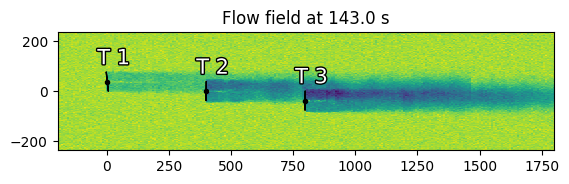

In [2]:
env.plot_farm()

## 2. Inspect action and observation spaces

WindGym environments follow the [Gymnasium API](https://gymnasium.farama.org/). The **action space** has one continuous value per turbine (yaw offset), and the **observation space** contains sensor readings configured in the preset.

In [3]:
print("Action space:     ", env.action_space)
print("Observation space:", env.observation_space)
print()
print("Sample action:     ", env.action_space.sample())
print("Sample observation:", env.observation_space.sample())

Action space:      Box(-1.0, 1.0, (3,), float32)
Observation space: Box(-1.0, 1.0, (9,), float32)

Sample action:      [-0.9132669   0.22406721  0.694032  ]
Sample observation: [-0.40198392 -0.4762251  -0.24990523  0.6599354  -0.7595762  -0.46604863
  0.01476535 -0.92110705  0.52803606]


## 3. Run a basic episode

Call `reset()` to start an episode, then repeatedly call `step(action)`. Each step returns an observation, a reward, termination flags, and an info dictionary with detailed simulation data.

In [4]:
import numpy as np

obs, info = env.reset()
total_reward = 0.0

for step in range(50):
    action = env.action_space.sample()  # random yaw offsets
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    if terminated or truncated:
        break

print(f"Episode finished after {step + 1} steps")
print(f"Total reward: {total_reward:.2f}")
print(f"Final farm power: {info['Power agent']:.0f} W")

Episode finished after 50 steps
Total reward: 0.00
Final farm power: 4686418 W


The `info` dictionary contains per-turbine and farm-level data for analysis:

In [6]:
for key in ['yaw angles agent', 'Wind speed Global', 'Wind direction Global',
            'Power agent', 'Power pr turbine agent']:
    print(f"{key}: {info[key]}")

yaw angles agent: [-1.41925812  6.36434174 -2.15040207]
Wind speed Global: 13.330917428842028
Wind direction Global: 269.658846545619
Power agent: 4686418.282370554
Power pr turbine agent: [1969368.05419074 1509426.06187233 1207624.16630749]


In [7]:
# Clean up
env.close()